In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 任选其一存在即可
mpl.rcParams['axes.unicode_minus'] = False

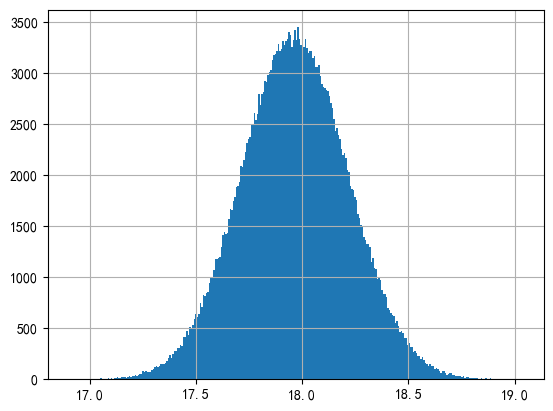

In [98]:
# 模拟
def get_dx(size=1):
    fps = 47 / 49.8 * np.random.uniform(0.23, 0.37, size=size) * 47
    x0 = np.random.choice([1.3, 1.4], size=size)
    dx = x0 * 0.01 * fps
    return dx

def get_x(t, size=1):
    x = get_dx(size=(size, t))
    return x.sum(axis=1)

# 示例：n=10 的和分布
t = 100
sn = get_x(t=t, size=300000)
pd.Series(sn).hist(bins=300)
plt.show()


In [106]:
# 理论
def get_norm(t):
    C = 0.01 * 47 * (47 / 49.8)
    E_x = (1.3 + 1.4) / 2
    E_v = (0.23 + 0.37) / 2
    E_x2 = (1.3 ** 2 + 1.4 ** 2) / 2
    E_v2 = (0.23 ** 2 + 0.23 * 0.37 + 0.37 ** 2) / 3

    mu = C * E_x * E_v * t
    sigma2 = C ** 2 * (E_x2 * E_v2 - E_x ** 2 * E_v ** 2) * t
    sigma = sigma2 ** 0.5
    return mu, sigma

mu, sigma = get_norm(np.arange(0, 2000))
fast, slow = mu + 3 * sigma, mu - 3 * sigma
fast, slow = 780 - fast, 819 - slow
fast[302]

724.4370601734404